In [186]:
import pandas as pd
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import geodatasets
from shapely.geometry import Point

In [187]:
# Helper functions.
# Convert the column names into same format.
def standardize_name(name):
    if pd.isna(name):
        return name
    return str(name).strip().lower().replace(" ", "_") 

# Convert the data in to uppercase.
def to_uppercase(x):
    if pd.isna(x):
        return x
    return str(x).upper()


In [207]:
# Load the datasets and check for NaN values.
df_vio = pd.read_csv("Violence_Reduction_-_Victims_of_Homicides_and_Non-Fatal_Shootings_20260302.csv")
df_stat = pd.read_csv("Public_Health_Statistics_-_Selected_public_health_indicators_by_Chicago_community_area_-_Historical_20260302.csv")

# Check if there is any data that doesn't have a value.
df_vio["COMMUNITY_AREA"].isna().sum()
df_stat["Community Area Name"].isna().sum()

# Drop rows where "COMMUNITY_AREA" column has nan vaule.
df_vio = df_vio.dropna(subset=["COMMUNITY_AREA"])

# Step 1: Ensure the column namse and the combine keys are having the same format.
df_vio.columns = [standardize_name(col) for col in df_vio.columns]
df_stat.columns = [standardize_name(col) for col in df_stat.columns]

# Step 2: Ensure the combine keys are having the same format.
# Check the information within the keys.
df_vio["community_area"].unique()
df_stat["community_area_name"].unique()

# Mapping for known mismatches, like O'Hare.
name_mapping = {"OHARE": "O'HARE", "Montclaire": "Montclare"}
df_vio["community_area"] = df_vio["community_area"].replace(name_mapping)
df_stat["community_area_name"] = df_stat["community_area_name"].replace(name_mapping)

df_vio["community_area"] = df_vio["community_area"].apply(to_uppercase)
df_stat["community_area_name"] = df_stat["community_area_name"].apply(to_uppercase)

# Step 3: Create crosswalk from number using df_stat as source of truth.
crosswalk = (df_stat[["community_area", "community_area_name"]].drop_duplicates()
             .set_index("community_area_name")["community_area"].to_dict())

# Step 4: Filter the df_stat with our desired year(2005-2010).
# Convert to datetime.
df_vio["date"] = pd.to_datetime(df_vio["date"], format="%m/%d/%Y %I:%M:%S %p")

df_vio["date_only"] = df_vio["date"].dt.date
df_vio["year"] = df_vio["date"].dt.year
df_vio["time"] = df_vio["date"].dt.time

# Step 5: Aggregate df_vio to community area by year. -> 沒看明白要怎麼做跟做什麼.....combine完再做感覺比較合理？！


# Step 6: Combine the two datasets with keys.
df_merged = pd.merge(df_vio, df_stat, left_on="community_area", right_on="community_area_name")

# Step 7: Validate the join.
vio_area = df_vio["community_area"].unique()
stat_area = df_stat["community_area_name"].unique()
merged_area = df_merged["community_area_x"].unique()

# Convert arrays to sets.
vio_set = set(vio_area)
stat_set = set(stat_area)
merged_set = set(merged_area)

# Check differences.
print("In vio_area but not in stat_area:", vio_set - stat_set)
print("In stat_area but not in vio_area:", stat_set - vio_set)

print("In vio_area but not in merged_area:", vio_set - merged_set)
print("In merged_area but not in vio_area:", merged_set - vio_set)

print("In stat_area but not in merged_area:", stat_set - merged_set)
print("In merged_area but not in stat_area:", merged_set - stat_set)

# Step 8: Filter the time period where both datasets overlap (2005 to 2010).
df_merged = df_merged[(df_merged["year"] >= 2005) & (df_merged["year"] <= 2010)]


# Output the results.
#df_vio["community_area"].head(5)
#df_vio["community_area"].value_counts()
# f_vio.shape
#df_vio.dtypes
#df_stat["community_area_name"].head(5)
#df_stat["community_area_name"].value_counts()
#df_stat.dtypes
#df_merged.head(5)
df_merged.head(5)


In vio_area but not in stat_area: set()
In stat_area but not in vio_area: set()
In vio_area but not in merged_area: set()
In merged_area but not in vio_area: set()
In stat_area but not in merged_area: set()
In merged_area but not in stat_area: set()


,case_number,date,block,victimization_primary,incident_primary,gunshot_injury_i,unique_id,zip_code,ward,community_area_x,...,childhood_lead_poisoning,gonorrhea_in_females,gonorrhea_in_males,tuberculosis,below_poverty_level,crowded_housing,dependency,no_high_school_diploma,per_capita_income,unemployment
47545,HS684556,2010-12-31 23:28:00,6700 S HALSTED ST,HOMICIDE,HOMICIDE,NO,HOM-HS684556-#1,60621.0,16.0,ENGLEWOOD,...,2.8,2594.9,2323.5,11.3,42.2,4.8,43.4,29.4,11993,21.3
47546,HS684468,2010-12-31 22:00:00,1200 S KEDZIE AVE,BATTERY,BATTERY,YES,SHOOT-HS684468-#1,60623.0,24.0,NORTH LAWNDALE,...,1.4,2529.9,2236.3,9.3,38.6,7.2,40.9,30.4,12548,18.5
47547,HS684414,2010-12-31 21:00:00,7700 S HERMITAGE AVE,BATTERY,BATTERY,YES,SHOOT-HS684414-#1,60620.0,17.0,AUBURN GRESHAM,...,1.5,2032.2,1986.7,7.3,24.5,4.1,42.1,19.5,16022,24.2
47548,HS684370,2010-12-31 20:00:00,3300 E 109TH ST,BATTERY,BATTERY,YES,SHOOT-HS684370-#1,60617.0,10.0,EAST SIDE,...,0.9,191.2,98.6,5.2,18.7,8.3,42.5,35.5,15347,14.5
47549,HS683411,2010-12-31 03:07:00,7400 N GREENVIEW AVE,BATTERY,BATTERY,YES,SHOOT-HS683411-#1,60626.0,49.0,ROGERS PARK,...,0.5,322.5,423.3,11.4,22.7,7.9,28.8,18.1,23714,7.5


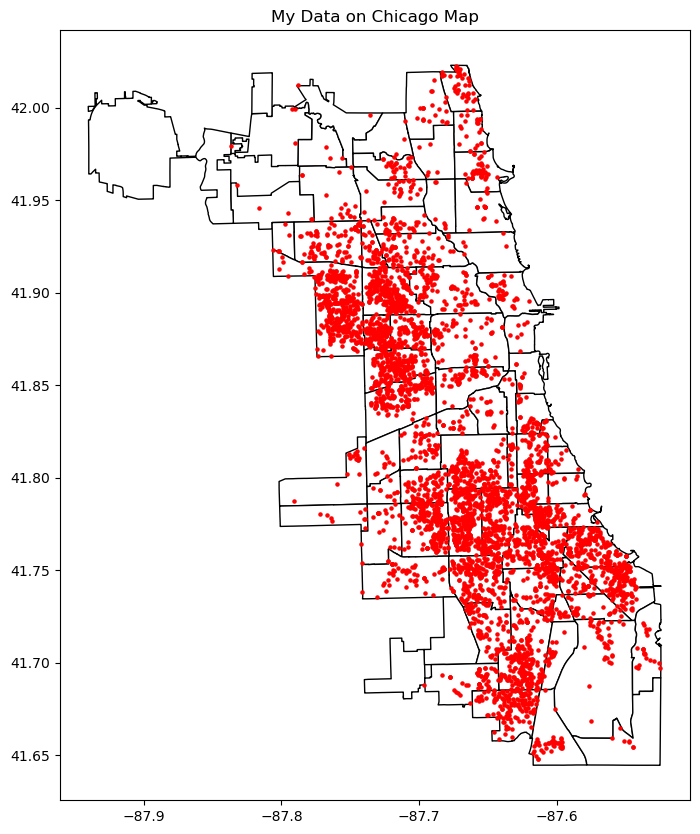

In [ ]:
# Method comes from: https://chatgpt.com/c/69cb28e5-c134-832d-9061-cced1c1fb5e6
# Chicago polygons
chicago = gpd.read_file(geodatasets.get_path("geoda.chicago_commpop"))

geometry = [Point(xy) for xy in zip(df_merged["longitude"], df_merged["latitude"])]

geo_df = gpd.GeoDataFrame(df_merged, geometry=geometry)

geo_df.set_crs(epsg=4326, inplace=True)

geo_df = geo_df.to_crs(chicago.crs)

fig, ax = plt.subplots(figsize=(10, 10))

# Base map
chicago.plot(ax=ax, color="white", edgecolor="black")

# Your points
geo_df.plot(ax=ax, color="red", markersize=5)

plt.title("My Data on Chicago Map")
plt.show()